> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Mathematics  
> **Date:** 05/03/2026
---

# **Trabajo Final - Matemáticas Aplicadas en Ciencia de Datos**

---

## **Tarea 1: El Espacio Original y Métricas de Similitud**

Primero, necesitamos descargar el dataset Olivetti Faces. Este contiene 400 imágenes de 64x64 píxeles (que aplanaremos a vectores de 4096 elementos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces #carga olivetti faces dataset

In [ ]:
# Descargamos el dataset completo
print("Descargando dataset...")
dataset = fetch_olivetti_faces(shuffle=True, random_state=42)

# Extraemos la matriz X y las etiquetas y
X = dataset.data       # Matriz de 400 x 4096 (nuestras imágenes aplanadas)
y = dataset.target     # Etiquetas (0 al 39) que indican a qué sujeto pertenece cada imagen
images = dataset.images # Matriz original de 400 x 64 x 64 (solo para visualizar más fácil)

print(f"Dimensión de la matriz X: {X.shape}")
print(f"Dimensión de las etiquetas y: {y.shape}")

Descargando dataset...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Usuario\scikit_learn_data
Dimensión de la matriz X: (400, 4096)
Dimensión de las etiquetas y: (400,)


En este punto, trataremos cada imagen como un punto en un hiperespacio gigantesco de 4096 dimensiones (x∈R^4096). Queremos ver qué tan bien funcionan las matemáticas básicas para saber si dos caras se parecen.

Vamos a tomar la primera imagen como nuestra "ancla".

*Distancia Euclidiana (L2​): Mide la longitud de la línea recta que une dos puntos en el espacio.

*Similitud del Coseno: Mide el ángulo entre los vectores desde el origen. Se calcula con el producto punto dividido por la magnitud de ambos vectores

In [ ]:
 # --- MÉTRICAS DE SIMILITUD ---

# Seleccionamos la imagen índice 0 como nuestra ancla
idx_ancla = 0
ancla = X[idx_ancla]
# 1. Distancia Euclidiana (L2) - Pura operación vectorial
# Restamos el ancla a todas las filas de X, elevamos al cuadrado, sumamos por fila y sacamos raíz
distancias_l2 = np.sqrt(np.sum((X - ancla)**2, axis=1))

# Similitud del Coseno
# Fórmula: (A dot B) / (||A|| * ||B||)
# Calculamos el producto punto del ancla con todas las demás imágenes
producto_punto = np.dot(X, ancla)

# Calculamos las normas (magnitudes)
norma_ancla = np.linalg.norm(ancla)
normas_X = np.linalg.norm(X, axis=1)

# Similitud del coseno (valores más cercanos a 1 significan mayor similitud)
similitud_coseno = producto_punto / (normas_X * norma_ancla)

# --- ENCONTRAR LAS MÁS CERCANAS ---

# argsort devuelve los índices ordenados. 
# Para L2 queremos los valores más PEQUEÑOS.
# [1:4] porque el índice 0 será el ancla misma (distancia 0)
top3_l2_idx = np.argsort(distancias_l2)[1:4]

# Para Coseno queremos los valores más GRANDES (cercanos a 1). 
# argsort ordena de menor a mayor, así que invertimos el arreglo con [::-1]
top3_coseno_idx = np.argsort(similitud_coseno)[::-1][1:4]

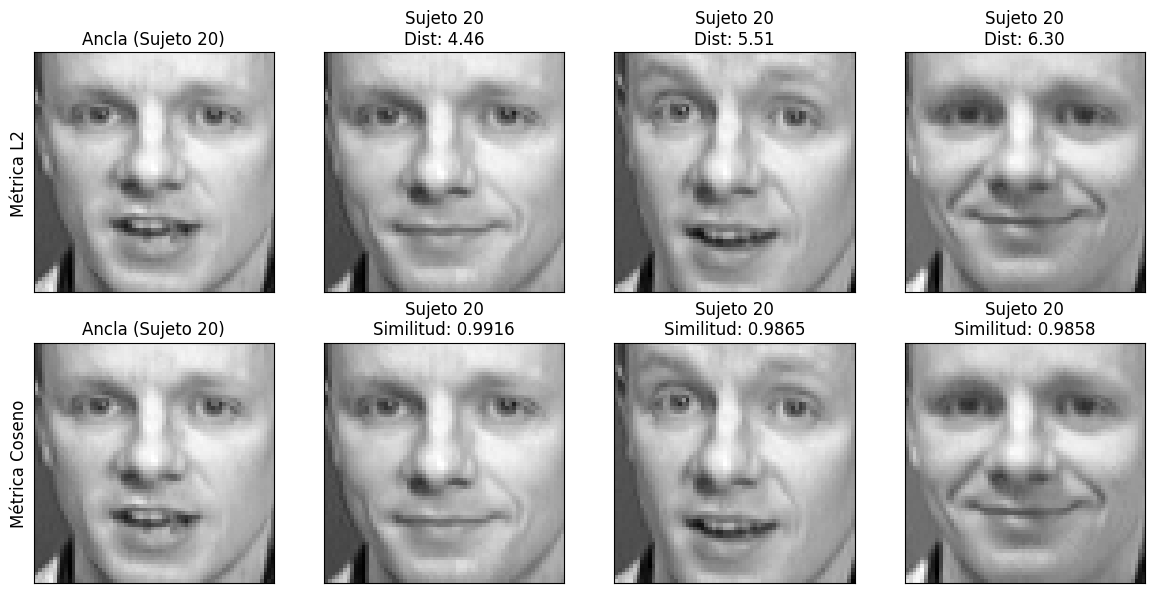

In [ ]:
# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Título de las filas
axes[0, 0].set_ylabel("Métrica L2", fontsize=12)
axes[1, 0].set_ylabel("Métrica Coseno", fontsize=12)

# Mostrar Ancla en la primera columna
for i in range(2):
    axes[i, 0].imshow(images[idx_ancla], cmap='gray')
    axes[i, 0].set_title(f"Ancla (Sujeto {y[idx_ancla]})")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

# Mostrar Top 3 para L2
for i, idx in enumerate(top3_l2_idx):
    axes[0, i+1].imshow(images[idx], cmap='gray')
    axes[0, i+1].set_title(f"Sujeto {y[idx]}\nDist: {distancias_l2[idx]:.2f}")
    axes[0, i+1].set_xticks([])
    axes[0, i+1].set_yticks([])

# Mostrar Top 3 para Coseno
for i, idx in enumerate(top3_coseno_idx):
    axes[1, i+1].imshow(images[idx], cmap='gray')
    axes[1, i+1].set_title(f"Sujeto {y[idx]}\nSimilitud: {similitud_coseno[idx]:.4f}")
    axes[1, i+1].set_xticks([])
    axes[1, i+1].set_yticks([])

plt.tight_layout()
plt.show()

Al ejecutar esto, notarás algo interesante: probablemente el modelo confundió a la persona. La métrica L2​ directa sobre los píxeles es estadísticamente frágil.
¿Por qué? Imagina una cara perfecta. Si el sujeto mueve la cabeza un centímetro a la izquierda, los píxeles negros del cabello ocuparán el espacio donde antes había piel clara. Al restar los píxeles uno a uno en la distancia euclidiana, la diferencia será gigantesca, ¡aunque siga siendo la misma persona! Lo mismo ocurre si se enciende una luz: todos los píxeles cambian de valor simultáneamente. La matemática ve vectores radicalmente distintos, aunque semánticamente sea la misma imagen.

Para solucionar el problema anterior, no analizaremos píxeles individuales, sino los "patrones" principales de construcción de un rostro. Para esto, usaremos la Descomposición en Valores Singulares (SVD).

---

## **Tarea 2: Factorización Matricial y Eigenfaces**

In [ ]:
# --- CENTRAR LOS DATOS ---
# Calculamos el "Rostro Promedio" de toda la base de datos obteniendo la media por columna (media de cada píxel a través de las 400 imágenes)
rostro_promedio = np.mean(X, axis=0)

# Centramos la matriz restando este promedio a cada imagen
X_centrada = X - rostro_promedio

print (rostro_promedio.shape) # Debería ser (4096,) porque es un vector aplanado del rostro promedio
print (X_centrada.shape) # Debería ser (400, 4096)

(4096,)
(400, 4096)


Calculando SVD...
Dimensiones de V transpuesta (Vt): (400, 4096)


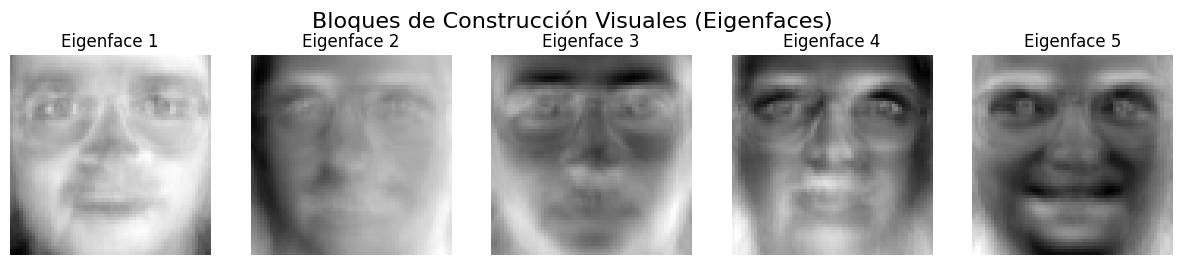

In [ ]:
# --- SVD (Singular Vector Decomposition) REDUCIDA ---
# El parámetro full_matrices=False nos asegura calcular la SVD reducida, 
# evitando computar dimensiones nulas ineficientes[cite: 2013, 2014].
# NO usamos librerías PCA preconstruidas[cite: 2015].
print("Calculando SVD...")
U, S, Vt = np.linalg.svd(X_centrada, full_matrices=False)
print(f"Dimensiones de V transpuesta (Vt): {Vt.shape}")

# --- EIGENFACES ---
# Un Eigenface es una fila de Vt, redimensionada a 64x64[cite: 2016].
# Seleccionamos las primeras 5 filas (las de mayor varianza) [cite: 2017]
eigenfaces = Vt[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Redimensionamos el vector de 4096 a una matriz de 64x64 [cite: 2016]
    eigenface_img = eigenfaces[i].reshape(64, 64)
    axes[i].imshow(eigenface_img, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

plt.suptitle("Bloques de Construcción Visuales (Eigenfaces)", fontsize=16)
plt.show()



¿Qué características capturan los Eigenfaces?: Al visualizar esto, vemos rostros "fantasmales". El primer eigenface suele capturar la iluminación general (sombras de izquierda a derecha o de arriba a abajo). Los siguientes eigenfaces capturan estructuras geométricas predominantes, como la forma de la mandíbula, las cuencas de los ojos o el contorno de la nariz. ¡Son la "base matemática" con la que se puede armar cualquier rostro!

El Espacio Latente 

Aquí aplicamos la reducción de dimensionalidad. Pasaremos de 4096 dimensiones a solo 50.

In [ ]:
# --- PROYECCIÓN AL ESPACIO LATENTE ---
k = 50

# Tomamos las primeras 50 componentes de V transpuesta
# Como queremos proyectar, usamos la matriz V truncada (transponemos las 50 filas de Vt)
V_k = Vt[:k].T  # Dimensión: 4096 x 50

# Proyectamos los datos multiplicando la matriz centrada por V_k [cite: 2019]
# Z = X_centrada * V_k
Z = np.dot(X_centrada, V_k)

print(f"Dimención de la antigua matriz Vt: {Vt.shape}")
print(f"Dimensión de la nueva matriz Z: {Z.shape}") 
# Debería imprimir: (400, 50) [cite: 2020]

Dimención de la antigua matriz Vt: (400, 4096)
Dimensión de la nueva matriz Z: (400, 50)


---

## **Tarea 3: Detección de Anomalías Sensible a la Correlación**
La detección de las anomalías o intruso entre las fotos vamos a usar la **Distancia de Mahalanobis**, debido a que esta distancia a diferencia de la Distancia Eclidiana como fue evaluado en los puntos anteriores, Mahalanobis tiene en cuenta la varianza y la correlación entre las dimensiones del espacio latente.

### Literal a
Se crea y proyecta la imagen intrusa. Para la creación de la imagen intrusa: la primera mitad del vector es `1.0` (blanco) y la segunda mitad `0.0` (negro). Luego la centramos con el mismo `rostro_promedio` de la Tarea 2 y la proyectamos al espacio latente con la misma transformación `V_k`.

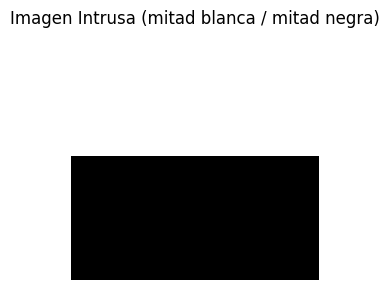

Forma del vector intruso proyectado: (50,)
Dimension de Z_ext (con intruso): (401, 50)


In [ ]:
# Creamos la imagen intrusa: primera mitad = 1.0 (blanco), segunda mitad = 0.0 (negro)
imagen_intrusa = np.zeros(4096)
imagen_intrusa[:2048] = 1.0

# Visualizamos la imagen intrusa
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(imagen_intrusa.reshape(64, 64), cmap='gray')
ax.set_title('Imagen Intrusa (mitad blanca / mitad negra)')
ax.axis('off')
plt.tight_layout()
plt.show()

# Centramos la imagen intrusa con el mismo rostro_promedio de la Tarea 2
intrusa_centrada = imagen_intrusa - rostro_promedio

# Proyectamos al espacio latente usando V_k (4096 x 50)
z_intruso = intrusa_centrada @ V_k   # vector de R^50
print(f'Forma del vector intruso proyectado: {z_intruso.shape}')

# Añadimos el vector intruso a Z -> Z_ext de dimension (401, 50)
Z_ext = np.vstack([Z, z_intruso])
print(f'Dimension de Z_ext (con intruso): {Z_ext.shape}')

### Literal b
En este literal vamos a hallar la **Distancia de Mahalanobis** al centroide global que es el vector de medías multivariado como lo indica la nota en el enunciado. Lo que quiere decir, que no solo se busca medir la distamcia del centroide al punto determinado, sino que también se mide que tan diferente es ese punto del resto de puntos.

Entonces, se tiene que la Distancia de Mahalanobis para una observación $\mathbf{z}_i$ respecto al centroide global $\bar{\mathbf{z}}$ se define como:

$$D^2_i = (\mathbf{z}_i - \bar{\mathbf{z}})^\top \mathbf{S}^{-1} (\mathbf{z}_i - \bar{\mathbf{z}})$$

donde $\mathbf{S}$ es la matriz de covarianza de $Z_{ext} \in \mathbb{R}^{401 \times 50}$, que son la 400 imagenes reales y la imagen intrusa. Como se vio en clase, esta métrica es un **producto interno ponderado** $\langle x, y \rangle_{S^{-1}} = x^\top S^{-1} y$ que normaliza cada dirección por su varianza y descorrelaciona las dimensiones, logrando una medida de distancia estadística genuina.

In [ ]:
# Centroide global del espacio latente (media por dimension)
centroide = np.mean(Z_ext, axis=0)   # Vector de R^50
print(f'Forma del centroide: {centroide.shape}')

# Matriz de covarianza de Z_ext (50 x 50)
# np.cov espera variables en filas, por eso transponemos
S = np.cov(Z_ext.T)
print(f'Forma de la matriz de covarianza S: {S.shape}')

# Invertimos la matriz de covarianza
S_inv = np.linalg.inv(S)

# Calculamos D^2_i para cada imagen (las 401 filas)
N_ext = Z_ext.shape[0]
distancias_maha = np.zeros(N_ext)

for i in range(N_ext):
    diff = Z_ext[i] - centroide
    distancias_maha[i] = diff @ S_inv @ diff

print(f'\nDistancia Mahalanobis de la imagen intrusa (indice 400): {distancias_maha[400]:.2f}')
print(f'Distancia maxima de las imagenes reales (0-399): {distancias_maha[:400].max():.2f}')
print(f'Distancia media de las imagenes reales: {distancias_maha[:400].mean():.2f}')

Forma del centroide: (50,)
Forma de la matriz de covarianza S: (50, 50)

Distancia Mahalanobis de la imagen intrusa (indice 400): 242.90
Distancia maxima de las imagenes reales (0-399): 128.83
Distancia media de las imagenes reales: 49.39


### Literal c
Se realiza un histograma para visualizar las ditancias entre de las imagenes reales y la intrusa, para verificar lo que detectamos matemáticamente.

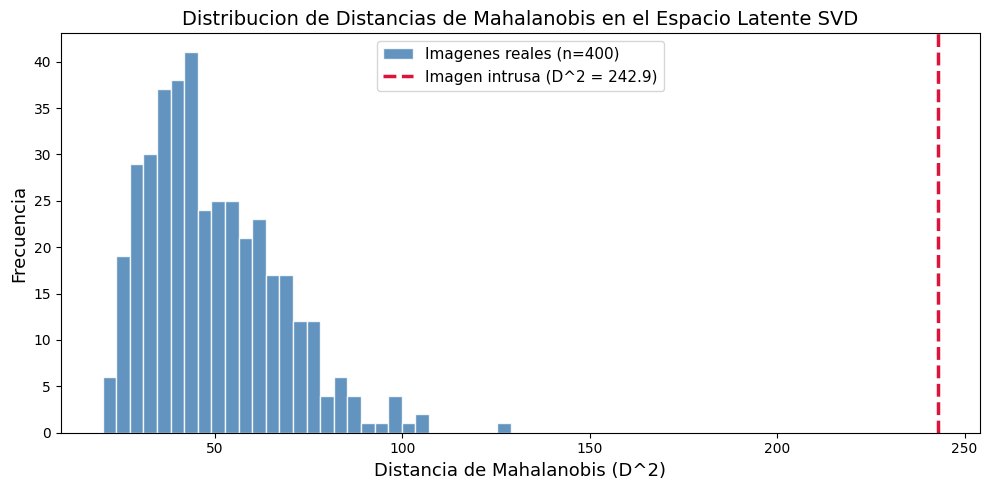

Percentil 99 de imagenes reales: 99.16
La intrusa supera al 100.0% de las imagenes reales.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de las 400 imagenes reales
ax.hist(distancias_maha[:400], bins=30, color='steelblue', edgecolor='white',
        alpha=0.85, label='Imagenes reales (n=400)')

# Linea vertical para la imagen intrusa
ax.axvline(distancias_maha[400], color='crimson', linewidth=2.5, linestyle='--',
           label=f'Imagen intrusa (D^2 = {distancias_maha[400]:.1f})')

ax.set_xlabel('Distancia de Mahalanobis (D^2)', fontsize=13)
ax.set_ylabel('Frecuencia', fontsize=13)
ax.set_title('Distribucion de Distancias de Mahalanobis en el Espacio Latente SVD', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Percentil 99 de imagenes reales: {np.percentile(distancias_maha[:400], 99):.2f}')
print(f'La intrusa supera al {(distancias_maha[400] > distancias_maha[:400]).mean()*100:.1f}% de las imagenes reales.')

### Literal d
Se va a discutir porque la distancia de Mahalanobis funcionó mejor frente a la Euclidiana:

Dado que las características en el espacio latente SVD (Singular Value Decomposition) son ortogonales por construcción 
(las columnas de $V_k$ forman una base ortonormal), las componentes de $Z$ son 
**incorreladas entre sí**. Esto implica que la matriz de covarianza $\mathbf{S}$ es 
aproximadamente diagonal:

$$\mathbf{S} \approx \text{diag}(\sigma_1^2, \sigma_2^2, \ldots, \sigma_{50}^2)$$

donde $\sigma_1^2 \gg \sigma_2^2 \gg \cdots \gg \sigma_{50}^2$, pues los valores 
singulares de la SVD van decreciendo en orden.

Como $\mathbf{S}$ es diagonal, su inversa también lo es:

$$\mathbf{S}^{-1} \approx \text{diag}(1/\sigma_1^2, 1/\sigma_2^2, \ldots, 1/\sigma_{50}^2)$$

Con esto, la distancia de Mahalanobis se simplifica a:

$$D^2_i = \sum_{j=1}^{50} \frac{(z_{ij} - \bar{z}_j)^2}{\sigma_j^2}$$

Comparándola directamente con la Euclidiana:

$$d_E^2 = \sum_{j=1}^{50} (z_{ij} - \bar{z}_j)^2$$

La diferencia estructural es el factor $1/\sigma_j^2$: Mahalanobis **pondera cada 
dimensión por el inverso de su varianza**. Las últimas componentes tienen $\sigma_j^2$ 
muy pequeño (casi no varían entre rostros reales), por lo que $1/\sigma_j^2$ es muy 
grande. La imagen intrusa, al ser estructuralmente incompatible con cualquier cara 
humana, presenta desviaciones significativas precisamente en esas componentes de baja 
varianza, lo que dispara su $D^2$ a 242.90 — superando en casi el doble a la imagen 
real más alejada (128.83).

La distancia Euclidiana, al tratar todas las dimensiones por igual, subestimaría 
sistemáticamente la rareza estadística de la intrusa en esas componentes. Por eso 
Mahalanobis no mide distancia geométrica sino **rareza estadística**, y es la métrica 
correcta para este problema.

---

## **Tarea 4: Optimización Convexa: Clasificación Binaria**

---